In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson


# Esercitazione 1

Probabilità p: 0.1
Valore atteso (mu): 100.0
Deviazione std (sigma): 9.49


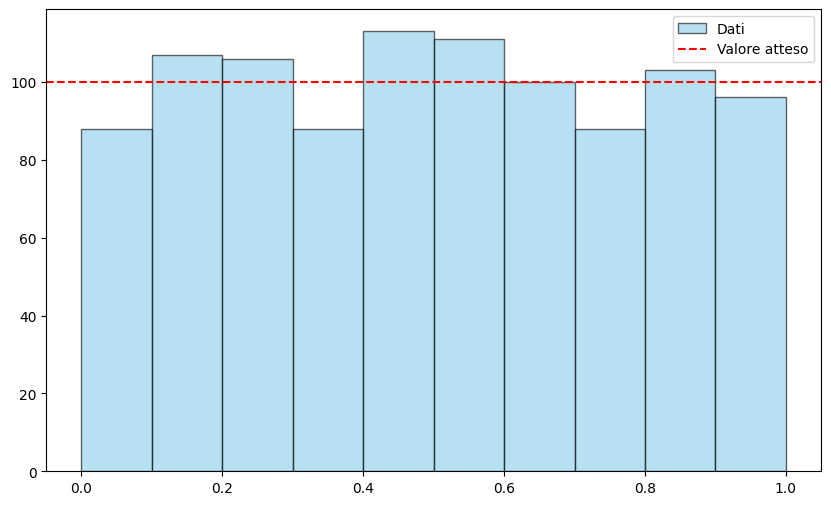

In [18]:
# Parametri iniziali
N = 1000
n_bins = 10

# Generazione dati e istogramma
dati = np.random.uniform(0, 1, N)

plt.figure(figsize=(10, 6))
# 'conteggi' riceve quanti eventi sono finiti in ogni colonna
conteggi, bordi, _ = plt.hist(dati, bins=n_bins, range=(0, 1), color='skyblue', alpha=0.6, label='Dati', edgecolor='black')

# Calcoli
p = 1 / n_bins
mu = N * p
sigma = np.sqrt(N * p * (1 - p))

print(f"Probabilità p: {p}")
print(f"Valore atteso (mu): {mu}")
print(f"Deviazione std (sigma): {sigma:.2f}")

# Linea del valore atteso
plt.axhline(mu, color='red', linestyle='--', label='Valore atteso')
plt.legend()
plt.show()

In [19]:
# Punto 2
M = 1000  # Numero ripetizioni
conteggi_bin = []

# Ciclo
for i in range(M):
    # Genero nuovi dati
    dati_temp = np.random.uniform(0, 1, N)

    # Calcolo istogramma
    conteggi, _ = np.histogram(dati_temp, bins=n_bins, range=(0, 1))

    # Prendo solo il numero di eventi caduti nel 5° bin (indice 4 perché si conta da 0)
    # E lo aggiungo alla mia lista 'conteggi_bin'
    conteggi_bin.append(conteggi[4])


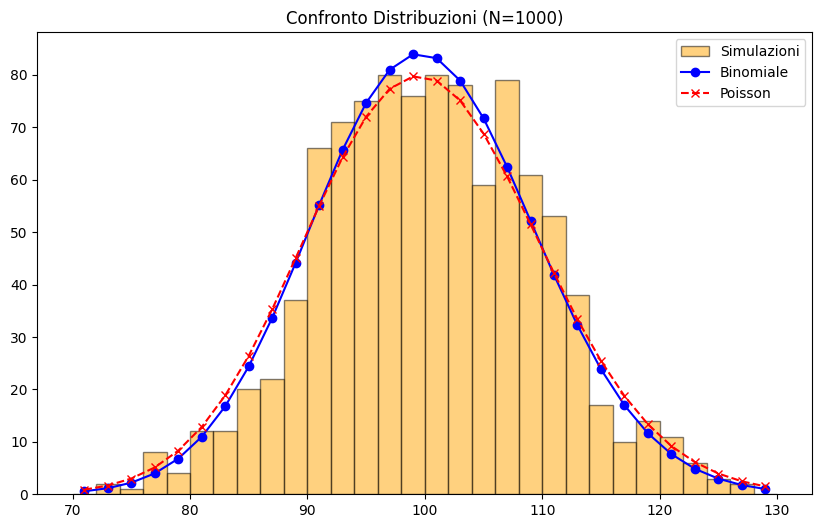

In [20]:
plt.figure(figsize=(10, 6))

# Istogramma dei risultati delle 1000 simulazioni
# Range [70, 130] e 30 bin
h, bordi, _ = plt.hist(conteggi_bin, bins=30, range=(70, 130), alpha=0.5, color='orange', edgecolor='black', label='Simulazioni')

# Calcolo centro dei bin e larghezza per le curve
centri = (bordi[:-1] + bordi[1:]) / 2
delta_x = bordi[1] - bordi[0] # Larghezza del bin (serve per scalare le curve)

# Curva Binomiale (Punto 3)
# binom.pmf calcola la probabilità teorica.
# Moltiplichiamo per M * delta_x per adattare l'altezza della curva all'istogramma dei conteggi.

y_binom = binom.pmf(np.floor(centri), N, p) * M * delta_x # floor serve a rendere intero il numero
plt.plot(centri, y_binom, 'b-o', label='Binomiale') # x; y; stile (blue; solid line; circle)

# Curva Poissoniana (Punto 4)
# La Poisson dipende solo da lambda (valore medio), che qui è N*p
lam = N * p
y_pois = poisson.pmf(np.floor(centri), lam) * M * delta_x
plt.plot(centri, y_pois, 'r--x', label='Poisson')

plt.legend()
plt.title(f'Confronto Distribuzioni (N={N})')
plt.show()

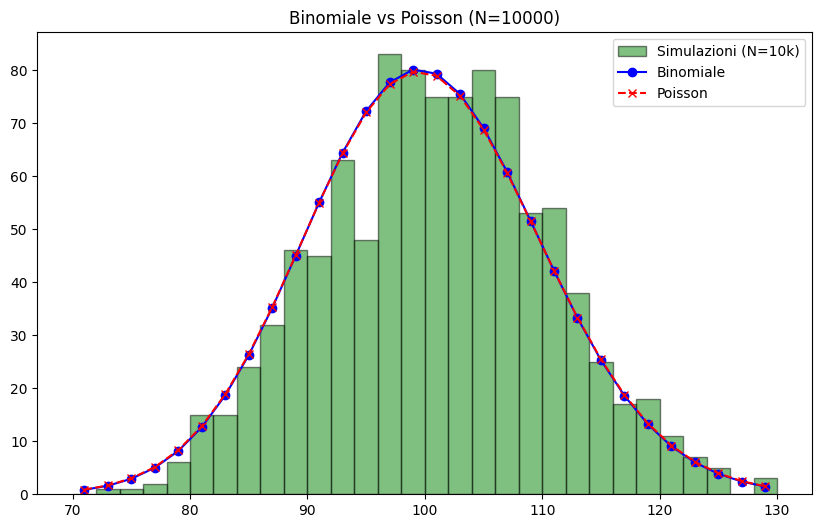

In [21]:
# Punto 5
N_2 = 10000
n_bins_2 = 100
p_2 = 1 / n_bins_2

conteggi_2 = []

# Ripeto la simulazione M volte
for i in range(M):
    dati_temporanei = np.random.uniform(0, 1, N_2)
    conteggi_temp, _ = np.histogram(dati_temporanei, bins=n_bins_2, range=(0, 1))
    conteggi_2.append(conteggi_temp[50])

# Grafico
plt.figure(figsize=(10, 6))

h, bordi, _ = plt.hist(conteggi_2, bins=30, range=(70, 130),
                       alpha=0.5, color='green', edgecolor='black', label='Simulazioni (N=10k)')

centri = (bordi[:-1] + bordi[1:]) / 2 #lati sinistri + destri / 2
delta_x = bordi[1] - bordi[0] #assumendo che abbia bin tutti equispaziati

# Binomiale
y_binom = binom.pmf(np.floor(centri), N_2, p_2) * M * delta_x
plt.plot(centri, y_binom, 'b-o', label='Binomiale')

# Poisson
lambda_2 = N_2 * p_2 # = 100
y_pois = poisson.pmf(np.floor(centri), lambda_2) * M * delta_x
plt.plot(centri, y_pois, 'r--x', label='Poisson')

plt.title('Binomiale vs Poisson (N=10000)')
plt.legend()
plt.show()

# Esercitazione 2

## Parte A

In [22]:
import numpy as np
import matplotlib.pyplot as plt

<>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_19528\45060328.py:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.errorbar(centri_bin, conteggi, yerr=errori, fmt='.', color='black', label='Errore $\sqrt{N}$')


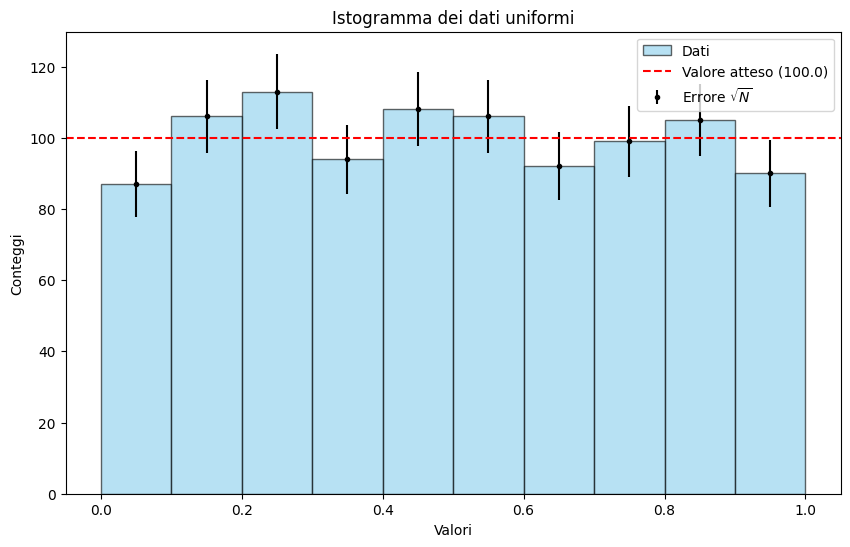

In [23]:
N = 1000
dati_uni = np.random.uniform(0, 1, N)
p = 1 / 10
mu = N * p 

plt.figure(figsize=(10, 6))
conteggi, bordi, _ = plt.hist(dati_uni, bins=10, range=(0, 1), 
                              color='skyblue', alpha=0.6, label='Dati', edgecolor='black')

# AGGIUNGO GLI ERRORI
#calcolo il centro di ogni bin per posizionare l'errore
centri_bin = (bordi[:-1] + bordi[1:]) / 2
errori = np.sqrt(conteggi)  # Radice dei conteggi

plt.errorbar(centri_bin, conteggi, yerr=errori, fmt='.', color='black', label='Errore $\sqrt{N}$')

plt.axhline(mu, color='red', linestyle='--', label=f'Valore atteso ({mu})')

plt.xlabel('Valori')
plt.ylabel('Conteggi')
plt.title('Istogramma dei dati uniformi')
plt.legend()
plt.show()

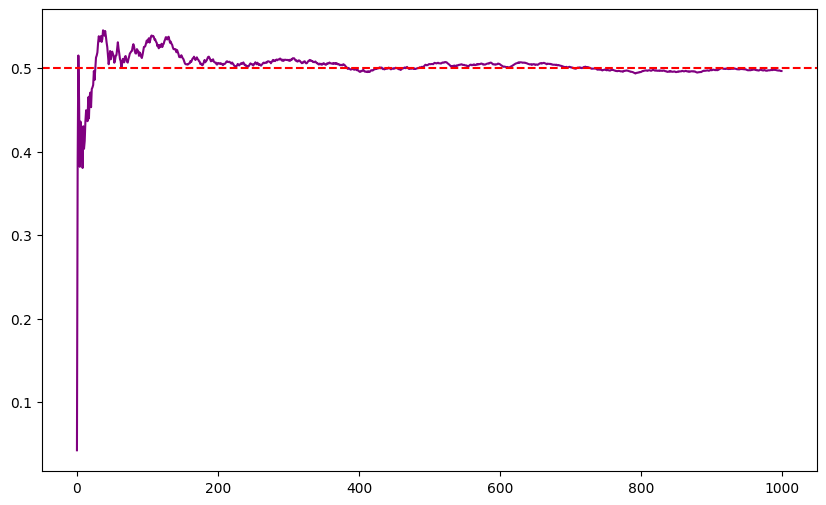

In [24]:
medie = []
mu = 0.5  

for i in range(N):
    miao = np.mean(dati_uni[:i+1])
    medie.append(miao)


plt.figure(figsize=(10, 6)) 
plt.plot(medie, color='purple', label='Medie')
plt.axhline(mu, color='red', linestyle='--', label='Valore atteso')

<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_19528\2855445725.py:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.errorbar(centri, conteggi, yerr=errori, fmt='.', color='black', label='Errore $\sqrt{N}$')


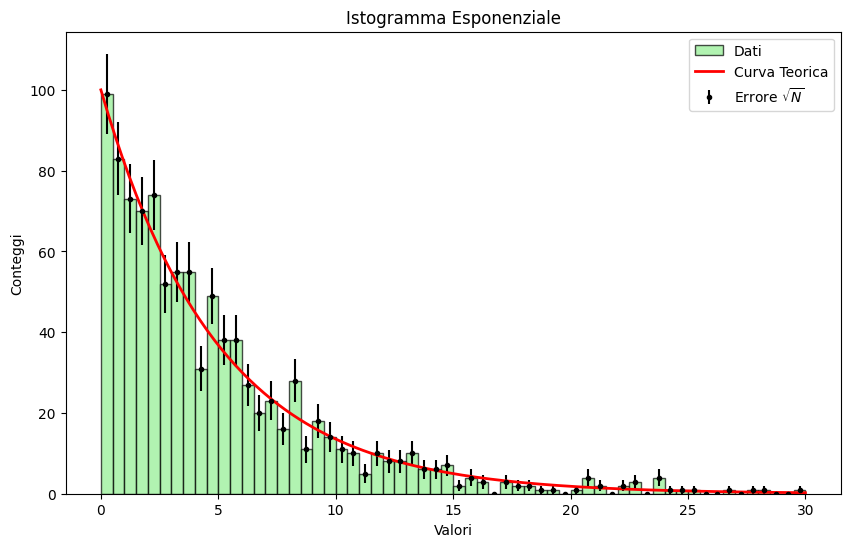

In [25]:

N = 1000
tau = 5
dati_uni = np.random.uniform(0, 1, N)
data_exp = -tau * np.log(1 - dati_uni)

n_bins = 60
raggio = (0, 30)
bin_width = (raggio[1] - raggio[0]) / n_bins # cioè 0.5

plt.figure(figsize=(10, 6))


conteggi, bordi, _ = plt.hist(data_exp, bins=n_bins, range=raggio, color='lightgreen', edgecolor='black', alpha=0.7, label='Dati')

# 4. AGGIUNGO ERRORI 
centri = (bordi[:-1] + bordi[1:]) / 2
errori = np.sqrt(conteggi)
plt.errorbar(centri, conteggi, yerr=errori, fmt='.', color='black', label='Errore $\sqrt{N}$')

#  LINEA TEORICA 
x = np.linspace(0, 30, 200) # Le X sono necessarie per allineare il grafico
y = N * bin_width * (1/tau * np.exp(-x/tau)) 

plt.plot(x, y, color='red', lw=2, label='Curva Teorica') # lw è lo spessore della linea

plt.xlabel('Valori')
plt.ylabel('Conteggi')
plt.title('Istogramma Esponenziale')
plt.legend()
plt.show()

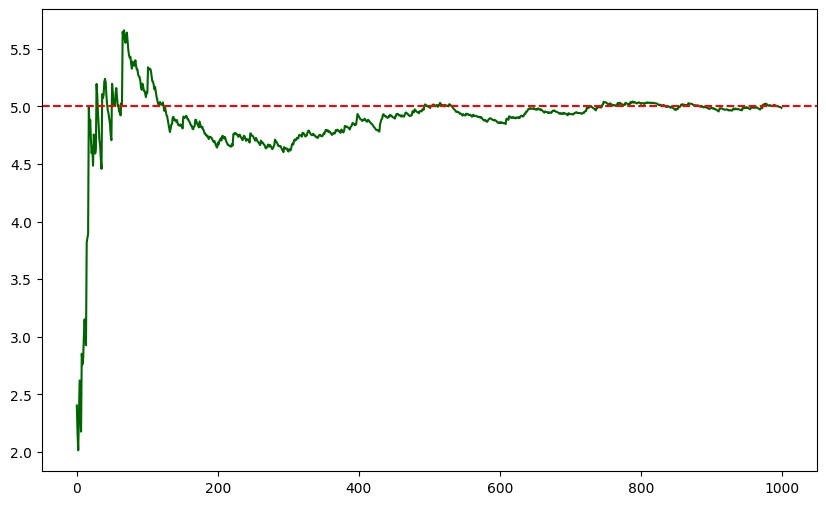

In [26]:
medie = []

for i in range(N):
    # Prendi i dati esponenziali dall'inizio fino all'indice i+1
    fetta_di_dati = data_exp[:i+1]
    
    # Calcola la media di questa fetta
    miao = np.mean(fetta_di_dati)
    
    medie.append(miao)


plt.figure(figsize=(10, 6)) 
plt.plot(medie, color='darkgreen', label='Medie')
plt.axhline(tau, color='red', linestyle='--', label='Valore atteso')

<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_19528\2276223806.py:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black', label='Errore $\sqrt{N}$')


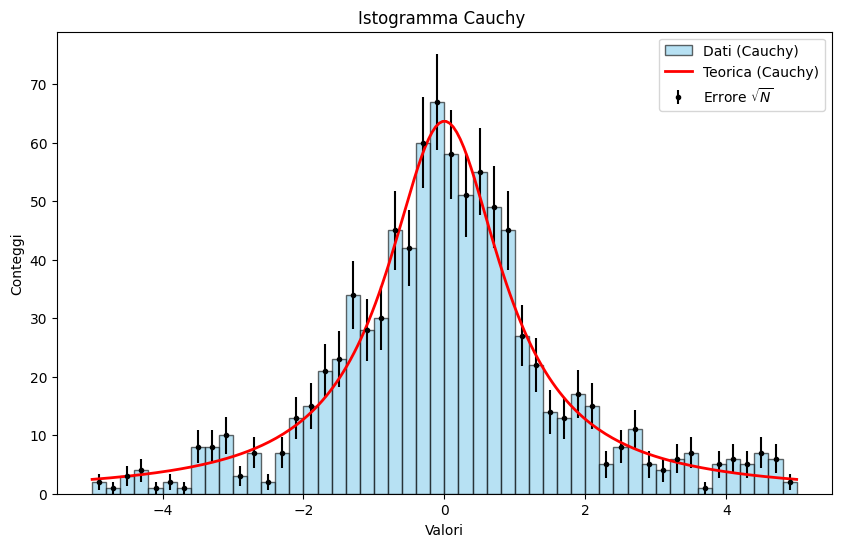

In [27]:
data_cauchy = np.random.randn(N) / np.random.randn(N)

plt.figure(figsize=(10, 6))
bin_range = (-5, 5)
bins_n = 50
bin_width = (bin_range[1] - bin_range[0]) / bins_n

conteggi, bordi, _ = plt.hist(data_cauchy, bins=bins_n, range=bin_range, 
                              color='skyblue', alpha=0.6, label='Dati (Cauchy)', edgecolor='black')

centri = (bordi[:-1] + bordi[1:]) / 2
plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black', label='Errore $\sqrt{N}$')

x = np.linspace(-5, 5, 200)
# Formula della PDF di Cauchy: 1 / (pi * (1 + x^2))
pdf_cauchy = 1 / (np.pi * (1 + x**2))
y_teorica = N * bin_width * pdf_cauchy

plt.plot(x, y_teorica, 'r-', lw=2, label='Teorica (Cauchy)')

plt.title("Istogramma Cauchy ")
plt.xlabel("Valori")
plt.ylabel("Conteggi")
plt.legend()
plt.show()

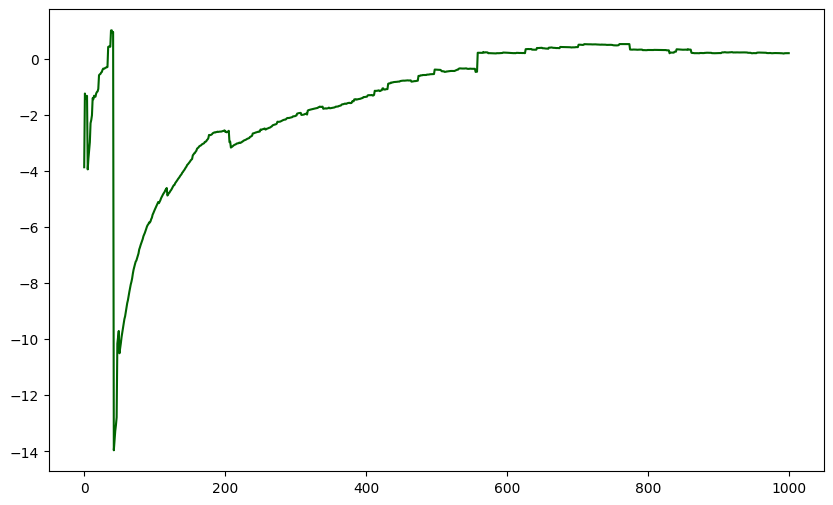

In [28]:
# Generazione dati Cauchy (rapporto di due normali)
medie = []

for i in range(N):
    # Prendi i dati esponenziali dall'inizio fino all'indice i+1
    fetta_di_dati = data_cauchy[:i+1]
    
    # Calcola la media di questa fetta
    miao = np.mean(fetta_di_dati)
    
    medie.append(miao)



plt.figure(figsize=(10, 6)) 
plt.plot(medie, color='darkgreen', label='Medie')


## Parte B

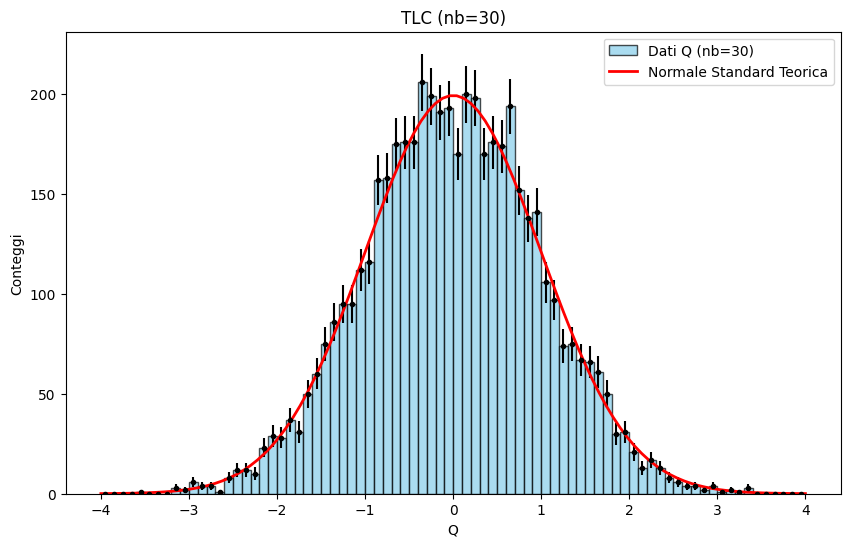

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

m = 5000
nb = 30  #  con 5, 30, 100
mu = 0.5
sigma = np.sqrt(1/12)

# Generiamo 5000 medie campionarie
medie_campionarie = []
for i in range(m):
    campione = np.random.uniform(0, 1, nb)
    medie_campionarie.append(np.mean(campione))

# 5. Calcoliamo la quantità Q
medie_campionarie = np.array(medie_campionarie)
Q = (medie_campionarie - mu) / (sigma / np.sqrt(nb))

# 6. Istogramma di Q (80 bins, range -4, 4)
plt.figure(figsize=(10, 6))
n_bins = 80
raggio = (-4, 4)
bin_width = (raggio[1] - raggio[0]) / n_bins

conteggi, bordi, _ = plt.hist(Q, bins=n_bins, range=raggio, color='skyblue', 
                              edgecolor='black', alpha=0.7, label=f'Dati Q (nb={nb})')

# Aggiungiamo errori (sqrt dei conteggi)
centri = (bordi[:-1] + bordi[1:]) / 2
plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black')

# 7. Sovrapponiamo la Normale Standard teorica
x = np.linspace(-4, 4, 100)
y_teorica = m * bin_width * norm.pdf(x, 0, 1) # m * ampiezza_bin * densità_normale
plt.plot(x, y_teorica, 'r-', lw=2, label='Normale Standard Teorica')

plt.title(f"TLC (nb={nb})")
plt.xlabel("Q")
plt.ylabel("Conteggi")
plt.legend()
plt.show()

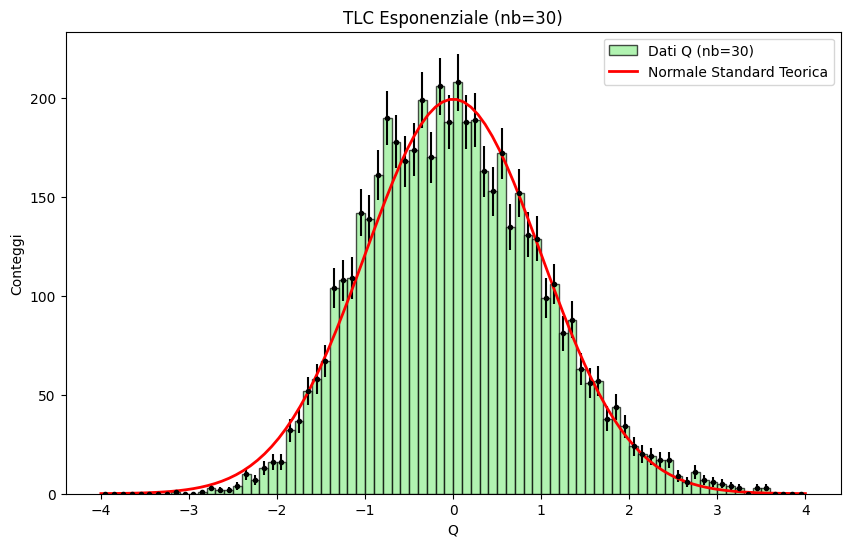

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

m = 5000
nb = 30  #  con 5, 30, 100
tau = 5
mu = tau
sigma = tau

# Generiamo le 5000 medie
medie_campionarie = []
for i in range(m):
    u = np.random.uniform(0, 1, nb)
    campione = -tau * np.log(1 - u)
    medie_campionarie.append(np.mean(campione))

medie_campionarie = np.array(medie_campionarie)
Q = (medie_campionarie - mu) / (sigma / np.sqrt(nb))

# Istogramma
plt.figure(figsize=(10, 6))
n_bins = 80
raggio = (-4, 4)
bin_width = (raggio[1] - raggio[0]) / n_bins

conteggi, bordi, _ = plt.hist(Q, bins=n_bins, range=raggio, color='lightgreen', 
                              edgecolor='black', alpha=0.7, label=f'Dati Q (nb={nb})')

centri = (bordi[:-1] + bordi[1:]) / 2
plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black')

# Normale Standard teorica
x = np.linspace(-4, 4, 100)
y_teorica = m * bin_width * norm.pdf(x, 0, 1)
plt.plot(x, y_teorica, 'r-', lw=2, label='Normale Standard Teorica')

plt.title(f"TLC Esponenziale (nb={nb})")
plt.xlabel("Q")
plt.ylabel("Conteggi")
plt.legend()
plt.show()

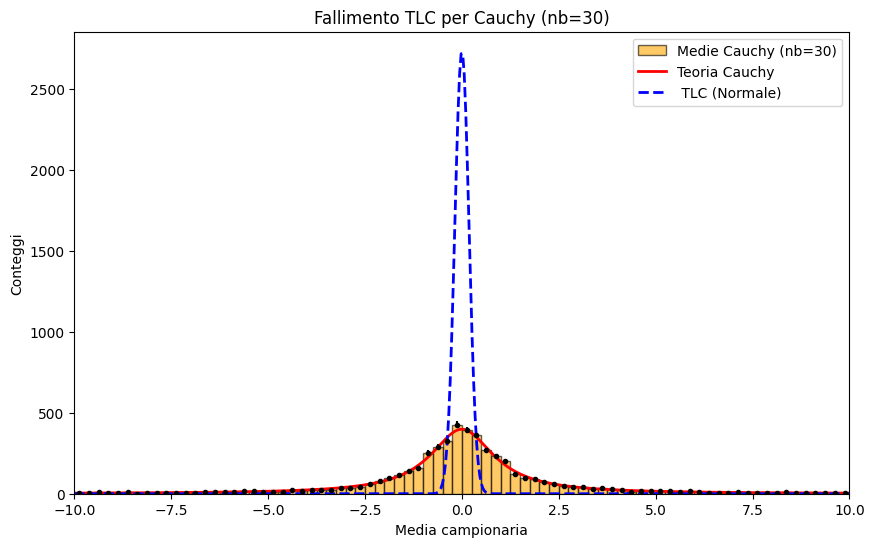

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

m = 5000
nb = 30  #  con 5, 30, 100

# Generiamo le medie campionarie
medie_campionarie = []
for i in range(m):
    campione = np.random.randn(nb) / np.random.randn(nb) # Generazione Cauchy
    medie_campionarie.append(np.mean(campione))

medie_campionarie = np.array(medie_campionarie)

plt.figure(figsize=(10, 6))
n_bins = 80
raggio = (-10, 10)
bin_width = (raggio[1] - raggio[0]) / n_bins

conteggi, bordi, _ = plt.hist(medie_campionarie, bins=n_bins, range=raggio, color='orange', 
                              edgecolor='black', alpha=0.6, label=f'Medie Cauchy (nb={nb})')

centri = (bordi[:-1] + bordi[1:]) / 2
plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black')

# Curve teoriche
x = np.linspace(-10, 10, 500)

# 1. Curva di Cauchy 
y_cauchy = m * bin_width * cauchy.pdf(x)
plt.plot(x, y_cauchy, 'r-', lw=2, label='Teoria Cauchy')

# 2. Curva Normale (quella che il TLC vorrebbe ma che qui fallisce)
# Per confronto uso sigma = 1/sqrt(nb) come se fosse una distribuzione normale
y_normale = m * bin_width * norm.pdf(x, 0, 1/np.sqrt(nb))
plt.plot(x, y_normale, 'b--', lw=2, label=' TLC (Normale)')

plt.title(f"Fallimento TLC per Cauchy (nb={nb})")
plt.xlabel("Media campionaria")
plt.ylabel("Conteggi")
plt.xlim(-10, 10)
plt.legend()
plt.show()